<h1 style="color:#1f77b4;">Impact of FOMC Announcements on SPY Returns and Volatility</h1>

# 1. Introduction

Financial markets closely monitor the decisions of the United States Federal Reserve, as changes in monetary policy directly influence interest rates, discount factors and overall risk sentiment. This project examines how FOMC interest rate changes impact the equity market.




In modern, highly transparent monetary regimes, the *direction* of the policy decision is often well anticipated by investors. As a result, **mean returns around FOMC announcements may not show strong or consistent patterns**, since markets tend to price in expected decisions ahead of time. Instead, the primary channel through which FOMC decisions influence asset prices is typically through **volatility**, as new information, uncertainty, and policy surprises affect market expectations.

The goal of this project is to empirically examine how FOMC announcements affect the daily behavior of the U.S. equity market, using the SPY ETF as a proxy for the S&P 500 index. Our analysis combines tools from time-series econometrics, including:

- An ARX model to test for abnormal **returns**, and  
- A GARCH(1,1) model to estimate and study **time-varying volatility**.

We construct a dataset of all FOMC meetings since december 2008 and merge it with daily SPY price and return data.

Based on both financial intuition and existing literature on announcement effects, we test the following hypotheses:

---

## Hypotheses

### **H1 — FOMC meetings increase stock market volatility.**  
Monetary policy announcements introduce uncertainty and new information, which should raise conditional volatility on announcement days.

### **H2 — The volatility response spills over to the next trading day.**  
Markets often continue adjusting after the announcement. Overnight international trading and post-meeting commentary may contribute to higher volatility the next day.

### **H3 — Larger rate changes generate larger volatility responses.**  
The magnitude of the policy rate adjustment should amplify market reactions and lead to higher volatility.

---

## Contribution of the Project

By combining ARX and GARCH models, the analysis separates:

- **Normal volatility dynamics** (captured by the GARCH process)  
 from  
- **Additional volatility caused by FOMC federal fund rate target announcements** (captured by regression on GARCH-estimated variance)

---

## Summary of the main empirical results

At the end of this project we prove statistically the impact of macroeconomic events (Federal Fund Target Rate) on market volatility and provide answers for the 3 hypotheses listed above.


In [ ]:
pip install pandas numpy matplotlib yfinance statsmodels arch #Installation of the required libraries

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from arch import arch_model
from datetime import datetime

---
# 2. Data Presentation

This project combines financial market data with monetary policy announcements to study how the Federal Reserve’s decisions affect stock market behavior. We construct a unified dataset containing daily SPY returns, FOMC event indicators, and changes in the federal funds rate.


---
## **2.1 SPY Price and Returns Data**

To measure equity-market reactions, we use daily data for **SPY**, the SPDR S&P 500 ETF, from **2008 to 2025**. SPY is highly liquid and widely used as a proxy for the U.S. stock market.

From the adjusted closing price series, we compute:

- **Daily log returns**  
  $
  r_t = \ln(P_t) - \ln(P_{t-1})
  $

Log returns are preferred because they are time-additive and more suitable for econometric models.

SPY returns exhibit characteristics typical of financial time series:
- volatility clustering  
- occasional large jumps  
- weak autocorrelation in returns  

These stylized facts motivate our later use of **ARX** and **GARCH** models.

In [ ]:
start = "2008-12-16"
end = datetime.today().strftime("%Y-%m-%d") #today

ticker = "SPY"   # S&P 500 ETF
data = yf.download(ticker, start=start, end=end)

# Keep adjusted close
data = data[['Close']].rename(columns={'Close': 'price'})
data.index = pd.to_datetime(data.index)

# Compute daily log return
data['ret'] = np.log(data['price']).diff()
data = data.dropna()
data.head()


/tmp/ipython-input-2630242755.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price,price,ret
Ticker,SPY,
Date,,
2008-12-17,66.380630,-0.009734
2008-12-18,65.140396,-0.018860
2008-12-19,64.860229,-0.004310
2008-12-22,64.029129,-0.012897
2008-12-23,63.367229,-0.010391


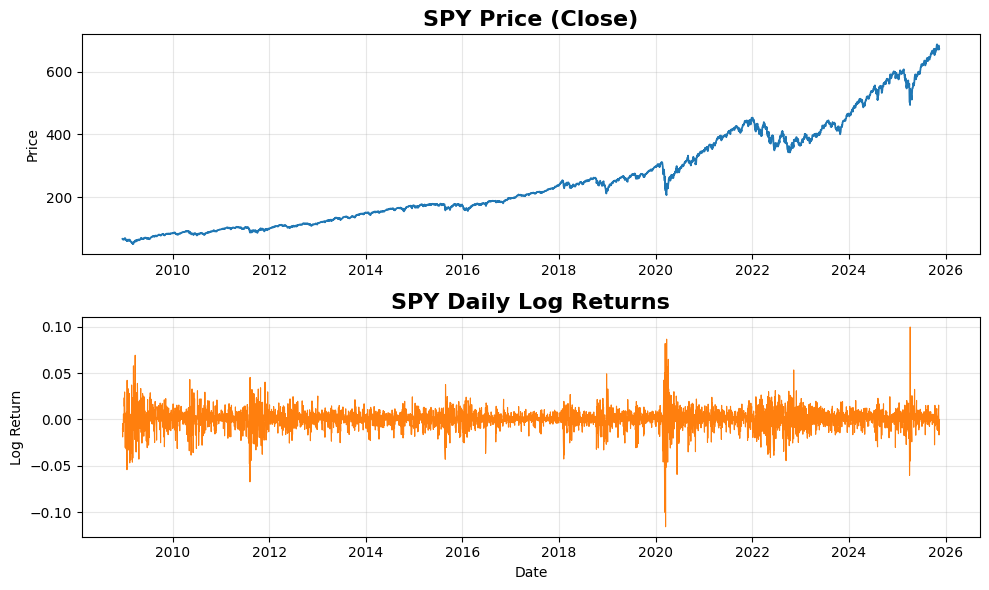

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Panel 1: Price
plt.subplot(2,1,1)
plt.plot(data.index, data['price'], linewidth=1.3)
plt.title("SPY Price (Close)", fontsize=16, fontweight='bold')
plt.ylabel("Price")
plt.grid(alpha=0.3)

# Panel 2: Daily Log Returns
plt.subplot(2,1,2)
plt.plot(data.index, data['ret'], linewidth=0.8, color='tab:orange')
plt.title("SPY Daily Log Returns", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


SPY daily log returns fluctuate around zero with no visible long-term trend, reflecting the absence of strong return autocorrelation in equity markets.  
Periods of heightened volatility appear as large spikes, illustrating the typical clustering behavior of financial returns.


---
## **2.2 FOMC Announcement Data**

We compile a dataset of all **FOMC meeting dates** from 2008 onward. For each meeting, we include:

- The **meeting date**  
- The **upper** and **lower** bounds of the federal funds target range  
- The **midpoint** of the range  
- The **change in the midpoint** relative to the previous meeting, noted as `d_rate`  

The rate change variable is constructed as:

$
d\_rate_t = \text{midpoint}_t - \text{midpoint}_{t-1}
$

This captures the size and direction of each monetary policy decision.

> **Note:**  
> To download SPY data using the API, you must provide your own API key.  
> Insert your key in the `API_KEY` variable before running the data import.  

In [ ]:
from os import read
import requests
import pandas as pd

API_KEY = "7c53970317d5b6ed2dce8b995ab5a1e9"

def get_fred_series(series_id):
    url = f"https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json",
        "observation_start": "2008-12-16",
        "observation_end": datetime.today().strftime("%Y-%m-%d") #today
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()["observations"]

    dates = [x["date"] for x in data]
    values = [float(x["value"]) if x["value"] != "." else None for x in data]
    return pd.Series(values, index=pd.to_datetime(dates))

# Download from FRED
upper = get_fred_series("DFEDTARU")
lower = get_fred_series("DFEDTARL")

df = pd.concat([upper, lower], axis=1)
df.columns = ["upper", "lower"]

# Drop empty values
df = df.dropna()

# Compute midpoint & changes
df["mid"] = (df["upper"] + df["lower"]) / 2
df["d_rate"] = df["mid"].diff()

# Meeting days = when target midpoint changes
meetings = df[df["d_rate"] != 0].copy()
meetings = meetings.reset_index().rename(columns={"index": "date"})

meetings = meetings[meetings["date"] >= "2004-01-01"]

# Save CSV
meetings.to_csv("fomc_rates.csv", index=False)


In [ ]:
fomc = pd.read_csv('fomc_rates.csv')
print(fomc.head(20))

          date  upper  lower    mid  d_rate
0   2008-12-16   0.25   0.00  0.125     NaN
1   2015-12-16   0.50   0.25  0.375    0.25
2   2016-12-14   0.75   0.50  0.625    0.25
3   2017-03-16   1.00   0.75  0.875    0.25
4   2017-06-15   1.25   1.00  1.125    0.25
5   2017-12-14   1.50   1.25  1.375    0.25
6   2018-03-22   1.75   1.50  1.625    0.25
7   2018-06-14   2.00   1.75  1.875    0.25
8   2018-09-27   2.25   2.00  2.125    0.25
9   2018-12-20   2.50   2.25  2.375    0.25
10  2019-08-01   2.25   2.00  2.125   -0.25
11  2019-09-19   2.00   1.75  1.875   -0.25
12  2019-10-31   1.75   1.50  1.625   -0.25
13  2020-03-04   1.25   1.00  1.125   -0.50
14  2020-03-16   0.25   0.00  0.125   -1.00
15  2022-03-17   0.50   0.25  0.375    0.25
16  2022-05-05   1.00   0.75  0.875    0.50
17  2022-06-16   1.75   1.50  1.625    0.75
18  2022-07-28   2.50   2.25  2.375    0.75
19  2022-09-22   3.25   3.00  3.125    0.75


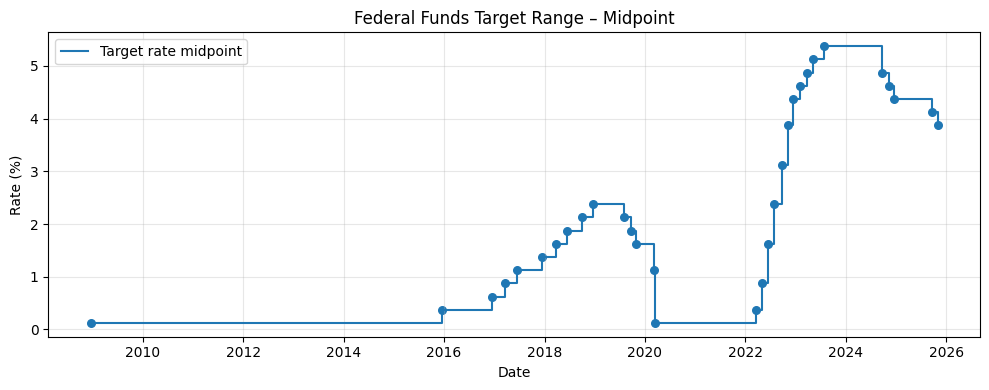

In [ ]:
# Load & prepare
fomc = pd.read_csv("fomc_rates.csv")
fomc["date"] = pd.to_datetime(fomc["date"])
fomc = fomc.sort_values("date")

plt.figure(figsize=(10,4))

plt.step(fomc["date"], fomc["mid"], where="post", label="Target rate midpoint")

plt.scatter(fomc["date"], fomc["mid"], s=30)  # dots on each meeting
plt.title("Federal Funds Target Range – Midpoint")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The federal funds rate remained at the zero lower bound from 2008 to 2015 as the Federal Reserve maintained an extremely accommodative policy stance after the financial crisis.  
Starting in late 2015, the Fed gradually tightened policy, followed by a sharp hiking cycle in 2022–2023 in response to high inflation.


In [ ]:
# Start from data index
df = data.copy()
df['D_meet'] = 0
df['D_meet_plus1'] = 0
df['D_meet_plus2'] = 0
df['d_rate'] = 0.0

# Convert FOMC dates are datetime
fomc['date'] = pd.to_datetime(fomc['date'])
meeting_dates = fomc['date']

trading_index = df.index  # DatetimeIndex of trading days

event0 = []
event1 = []
event2 = []
event0_rates = []

for d, dr in zip(meeting_dates, fomc['d_rate']):

    # find first trading day >= meeting date
    loc = trading_index.searchsorted(d)

    if loc < len(trading_index):

        # D_meet (event day)
        d0 = trading_index[loc]
        event0.append(d0)
        event0_rates.append(dr)

        # D_meet_plus1 (first trading day after)
        if loc + 1 < len(trading_index):
            d1 = trading_index[loc + 1]
            event1.append(d1)

        # D_meet_plus2 (second trading day after)
        if loc + 2 < len(trading_index):
            d2 = trading_index[loc + 2]
            event2.append(d2)

# Convert lists to DatetimeIndex
event0 = pd.DatetimeIndex(event0)
event1 = pd.DatetimeIndex(event1)
event2 = pd.DatetimeIndex(event2)

# Assign dummy variables
df.loc[df.index.isin(event0), 'D_meet'] = 1
df.loc[df.index.isin(event1), 'D_meet_plus1'] = 1
df.loc[df.index.isin(event2), 'D_meet_plus2'] = 1

# Assign rate change on the event day only
for d0, dr in zip(event0, event0_rates):
    if d0 in df.index:
        df.loc[d0, 'd_rate'] = dr

# Replace NaN rate changes with 0
df['d_rate'] = df['d_rate'].fillna(0.0)


In [ ]:
df.loc["2017-06-10":"2017-06-20",
       ['price',
        'ret',
        'D_meet',
        'D_meet_plus1',
        'D_meet_plus2',
        'd_rate']]


Price,price,ret,D_meet,D_meet_plus1,D_meet_plus2,d_rate
Ticker,SPY,,,,,
Date,,,,,,
2017-06-12,212.227951,-0.000206,0,0,0,0.00
2017-06-13,213.265762,0.004878,0,0,0,0.00
2017-06-14,212.995422,-0.001268,0,0,0,0.00
2017-06-15,212.585526,-0.001926,1,0,0,0.25
2017-06-16,212.631943,0.000218,0,1,0,0.00
2017-06-19,214.402130,0.008291,0,0,1,0.00
2017-06-20,212.956253,-0.006767,0,0,0,0.00


In [ ]:
# Flatten MultiIndex columns ONLY if MultiIndex exists
df.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in df.columns
]

print(df.columns)


Index(['price', 'ret', 'D_meet', 'D_meet_plus1', 'D_meet_plus2', 'd_rate'], dtype='object')


In [ ]:
# Copy full dataset
reg = df.copy()

# Lag of returns
reg['ret_lag1'] = reg['ret'].shift(1)

# Interaction term: size of rate change * event day
reg['d_rate_meet'] = reg['d_rate'] * reg['D_meet']

# Drop rows that cannot be used (NaN lag)
reg = reg.dropna(subset=['ret', 'ret_lag1'])

reg.head()


,price,ret,D_meet,D_meet_plus1,D_meet_plus2,d_rate,ret_lag1,d_rate_meet
Date,,,,,,,,
2008-12-18,65.140396,-0.018860,0,1,0,0.0,-0.009734,0.0
2008-12-19,64.860229,-0.004310,0,0,1,0.0,-0.018860,0.0
2008-12-22,64.029129,-0.012897,0,0,0,0.0,-0.004310,0.0
2008-12-23,63.367229,-0.010391,0,0,0,0.0,-0.012897,0.0
2008-12-24,63.734932,0.005786,0,0,0,0.0,-0.010391,0.0


---
# 3 Modelization

---
### 3.1 ARX Return Model Construction

To measure how equity returns respond to Federal Reserve monetary policy decisions, we estimate an ARX (AutoRegressive with eXogenous variables) model of daily SPY log returns. The specification incorporates both market dynamics and the event structure of FOMC announcements:

$$
r_t = \alpha
      + \phi r_{t-1}
      + \delta_0 D_t^{\text{meet}}
      + \delta_1 D_{t+1}^{\text{meet}}
      + \delta_2 D_{t+2}^{\text{meet}}
      + \theta \left( d\_r_t \cdot D_t^{\text{meet}} \right)
      + \varepsilon_t
$$

#### **Model Components**

- **$r_t$** – daily log return of SPY.  
- **$r_{t-1}$** – lagged return, capturing short-term autocorrelation (AR(1) dynamics).  
- **$D_t^{\text{meet}}$** – dummy equal to 1 on the first trading day of an FOMC meeting.  
- **$D_{t+1}^{\text{meet}}$** and **$D_{t+2}^{\text{meet}}$** – dummies for the first and second trading days after the meeting, capturing potential spillover effects.  

#### **Rate Shock Term**

The Fed only changes the policy rate on meeting days. To correctly capture the impact of the *size* of the rate decision, we include the interaction term:

$$
d\_rate\_meet = d\_rate \times D_t^{\text{meet}}
$$

In [ ]:
import statsmodels.api as sm

# Dependent variable: daily return
Y = reg['ret']

# Explanatory variables:
# - AR(1): ret_lag1
# - Event window: 0, +1, +2
# - Rate shock: only via interaction on meeting day (d_rate_meet)
X = reg[[
    'ret_lag1',
    'D_meet',
    'D_meet_plus1',
    'D_meet_plus2',
    'd_rate_meet'
]]

# Add constant
X = sm.add_constant(X)

# HAC-standard-errors OLS
model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.647
Date:                Sun, 16 Nov 2025   Prob (F-statistic):             0.0214
Time:                        10:10:29   Log-Likelihood:                 13057.
No. Observations:                4254   AIC:                        -2.610e+04
Df Residuals:                    4248   BIC:                        -2.606e+04
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0007      0.000      4.024   

### Interpretation of the ARX Return Regression

The ARX model shows **no significant abnormal returns** around FOMC meetings:

- **$D_{\text{meet}}$ (meeting day):** not significant  
- **$D_{\text{meet+1}}$ (next day):** not significant  
- **$D_{\text{meet+2}}$ (two days later):** not significant  

The coefficient on the rate-change shock:

- **$d\_rate_{\text{meet}}$:** not significant  

indicates that the **size of the policy move does not generate systematic return jumps**.

The only significant predictor is the lagged return (**mean reversion**), which is common in daily equity data.

**Overall:** SPY returns do not exhibit abnormal movements around FOMC announcements, consistent with the idea that policy news is rapidly absorbed by the market (efficient markets).


---
### *3.2* Modeling Volatility with GARCH(1,1)

Financial returns exhibit time-varying volatility and clustering (periods of calm followed by periods of high turbulence). Because OLS assumes constant variance, we estimate a GARCH model to capture the **expected level of volatility** each day.

We use a standard **GARCH(1,1)**:

- **Mean:**  
  $r_t = \mu + \varepsilon_t$

- **Volatility:**  
  $$h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}$$

Here, $\alpha$ measures how shocks raise volatility, while $\beta$ measures persistence.  
This model produces the conditional variance $h_t$, which we later compare to FOMC event dummies to test whether volatility rises unusually on meeting days.


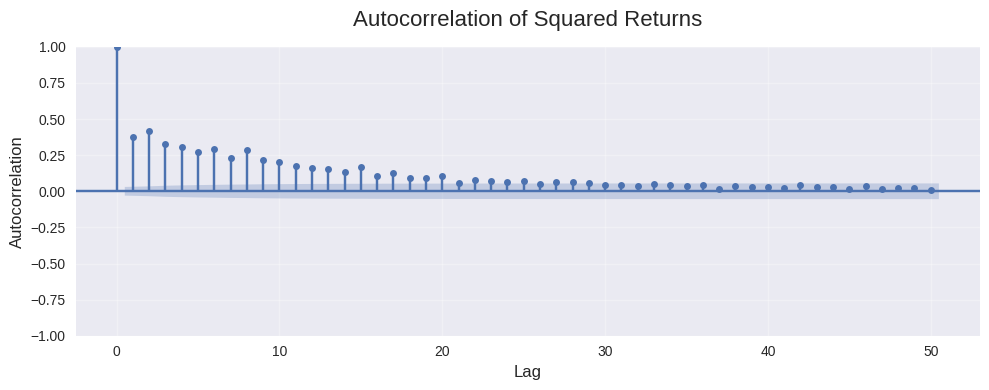

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(10, 4))

plot_acf((100 * reg['ret'])**2, lags=50, ax=ax)

ax.set_title("Autocorrelation of Squared Returns", fontsize=16, pad=15)
ax.set_xlabel("Lag", fontsize=12)
ax.set_ylabel("Autocorrelation", fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The squared returns exhibit strong positive autocorrelation that decays across lags, indicating clear volatility clustering. This behavior confirms that volatility is time-varying, which justifies estimating a GARCH model.


In [ ]:
garch_df = reg.copy()   # same reg dataframe as before

# Scale returns to % (GARCH is happier)
y = 100 * garch_df['ret']

# GARCH(1,1)
am_11 = arch_model(y, mean='Constant', vol='Garch', p=1, q=1, dist='normal')
res_11 = am_11.fit(update_freq=10, disp='off')

# GARCH(2,1)
am_21 = arch_model(y, mean='Constant', vol='Garch', p=2, q=1, dist='normal')
res_21 = am_21.fit(update_freq=10, disp='off')

# GARCH(2,2)
am_22 = arch_model(y, mean='Constant', vol='Garch', p=2, q=2, dist='normal')
res_22 = am_22.fit(update_freq=10, disp='off')

print("GARCH(1,1): AIC =", res_11.aic, "BIC =", res_11.bic)
print("GARCH(2,1): AIC =", res_21.aic, "BIC =", res_21.bic)
print("GARCH(2,2): AIC =", res_22.aic, "BIC =", res_22.bic)


GARCH(1,1): AIC = 11236.163617750342 BIC = 11261.586077733384
GARCH(2,1): AIC = 11233.362789561506 BIC = 11265.140864540308
GARCH(2,2): AIC = 11234.241091481106 BIC = 11272.374781455666


We retain the GARCH(1,1) model because it is the simplest model and is able to capture the volatility dynamics: higher-order models provide only negligible AIC improvements and are penalized by BIC, indicating that the standard GARCH(1,1) is sufficient.


In [ ]:
from arch import arch_model
import numpy as np
import statsmodels.api as sm

garch_df = reg.copy()   # same reg dataframe as before

# Scale returns to % (GARCH is happier)
y = 100 * garch_df['ret']

am = arch_model(y, mean='constant', vol='Garch', p=1, q=1, dist='normal')
res = am.fit(update_freq=10)
print(res.summary())


Iteration:     10,   Func. Count:     61,   Neg. LLF: 5614.081808875171
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5614.081808875171
            Iterations: 11
            Function evaluations: 65
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5614.08
Distribution:                  Normal   AIC:                           11236.2
Method:            Maximum Likelihood   BIC:                           11261.6
                                        No. Observations:                 4254
Date:                Sun, Nov 16 2025   Df Residuals:                     4253
Time:                        10:10:31   Df Model:                            1
        

### Interpretation of the GARCH(1,1) Estimation

The GARCH(1,1) model is well estimated and displays the typical characteristics of
equity-index volatility.

#### **Mean Equation**
- The constant mean is **μ = 0.0865% per day**, and highly significant.
- This corresponds to an annualized mean return of roughly 22%, which is reasonable
for SPY over a long sample.

#### **Volatility Equation**
- **ARCH term (α = 0.1548)**: highly significant, indicating that large shocks
increase next-day volatility. This captures the short-term reaction of volatility.
- **GARCH term (β = 0.8195)**: also highly significant, showing strong persistence
in volatility.
- **Persistence (α + β ≈ 0.97)**: very close to 1, implying long-lasting volatility
clusters. This is characteristic of financial return series.
- **ω (constant)** is small and significant.



In [ ]:

# Extract conditional volatility
sigma_t = res.conditional_volatility


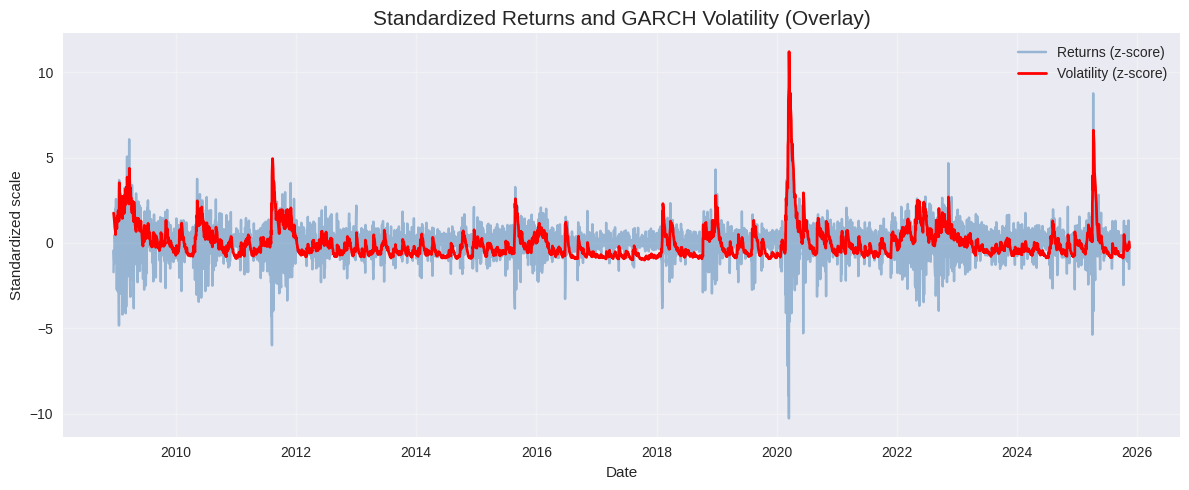

In [ ]:
# Use your existing SPY return series
ret_pct = garch_df['ret'] * 100      # convert to % (optional)

# Standardize returns and volatility
ret_z = (ret_pct - ret_pct.mean()) / ret_pct.std()
vol_z = (sigma_t - sigma_t.mean()) / sigma_t.std()

plt.figure(figsize=(12,5))

plt.plot(garch_df.index, ret_z, color="steelblue", alpha=0.5, label="Returns (z-score)")
plt.plot(garch_df.index, vol_z, color="red", linewidth=2, label="Volatility (z-score)")

plt.title("Standardized Returns and GARCH Volatility (Overlay)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Standardized scale")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Conditional volatility moves smoothly through time and peaks in crisis periods, while daily returns show sharp spikes. This confirms that our estimation of the volatility is valid.


/tmp/ipython-input-3264579446.py:25: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


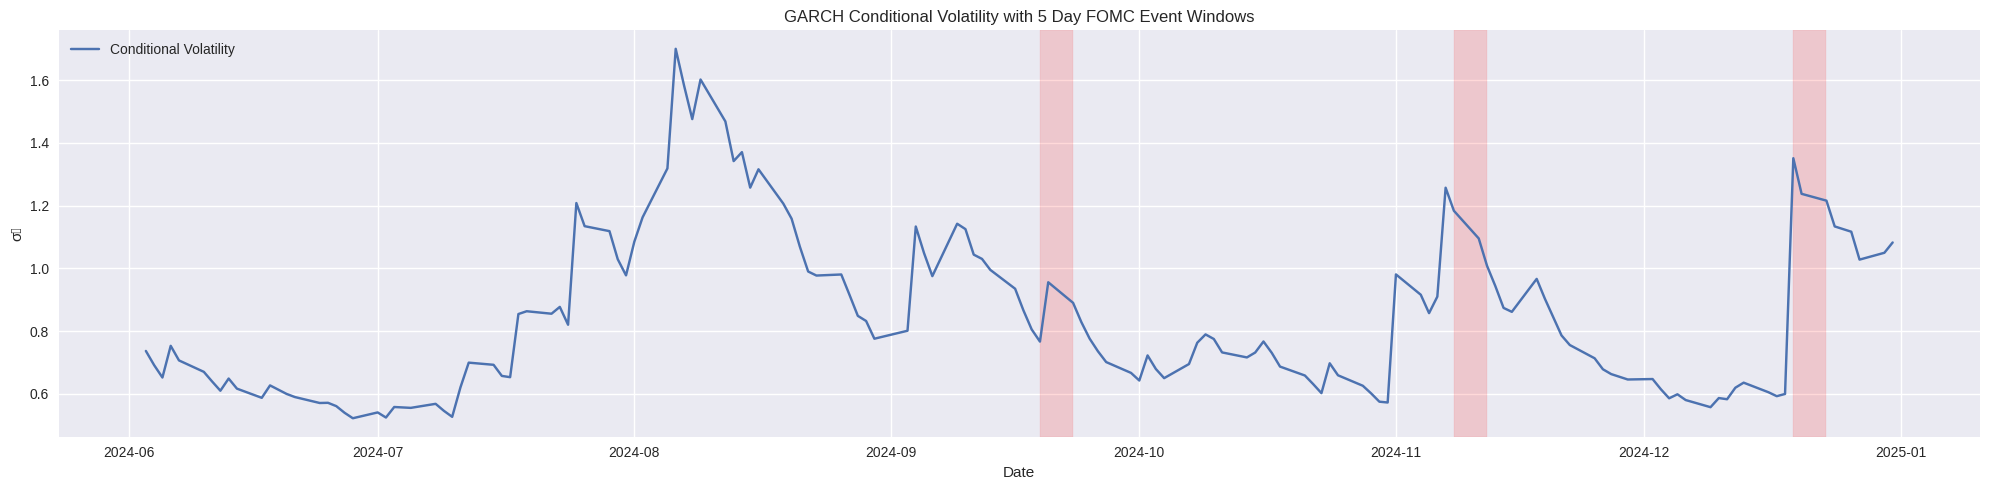

In [ ]:
plt.figure(figsize=(20,5))

start_zoom = "2024-06-01"
end_zoom = "2024-12-31"
mask_zoom = (garch_df.index >= start_zoom) & (garch_df.index <= end_zoom)

dates_zoom = garch_df.index[mask_zoom]
sigma_zoom = sigma_t[mask_zoom]

plt.plot(dates_zoom, sigma_zoom, label="Conditional Volatility")

# Shade 3-day window from meeting date
for d in garch_df.index[garch_df['D_meet'] == 1]:
    if d >= pd.to_datetime(start_zoom) and d <= pd.to_datetime(end_zoom):
        start_band = d
        end_band = d + pd.Timedelta(days=4)

        plt.axvspan(start_band, end_band,
                    color='red', alpha=0.15)

plt.title("GARCH Conditional Volatility with 5 Day FOMC Event Windows")
plt.xlabel("Date")
plt.ylabel("σₜ")
plt.legend()
plt.tight_layout()
plt.show()


The graph displays the GARCH(1,1) conditional volatility of SPY over the selected period (second half of 2024/ we restricted to 2024 for a better visualization), with each Federal Reserve FOMC meeting highlighted by a five-day shaded region (meeting day + 4 following trading days).  
The blue line represents the model-implied volatility. We can notice that usually following the day of the Federal Funds Target Rate change volatility spikes which proves which proves the effect of these announcements on the equity market.


In [ ]:
# Conditional volatility (sigma_t)
sigma_t = res.conditional_volatility

# Conditional variance h_t = sigma_t^2
h_t = sigma_t ** 2

# Base volatility dataframe
vol_df = pd.DataFrame({'h': h_t}, index=garch_df.index)

# Log variance (to reduce skewness)
vol_df['log_h'] = np.log(vol_df['h'])

# Add the FOMC event-window variables
vol_df['D_meet']        = garch_df['D_meet']
vol_df['D_meet_plus1']  = garch_df['D_meet_plus1']
vol_df['D_meet_plus2']  = garch_df['D_meet_plus2']

# Absolute size of the rate change
vol_df['abs_d_rate'] = garch_df['d_rate'].abs()

# Drop any remaining missing values
vol_df = vol_df.dropna()

vol_df.head()


,h,log_h,D_meet,D_meet_plus1,D_meet_plus2,abs_d_rate
Date,,,,,,
2008-12-18,3.794860,1.333647,0,1,0,0.0
2008-12-19,3.745493,1.320553,0,0,1,0.0
2008-12-22,3.144902,1.145783,0,0,0,0.0
2008-12-23,2.903952,1.066073,0,0,0,0.0
2008-12-24,2.609545,0.959176,0,0,0,0.0


  ## Final Volatility Model Construction

  We estimate the following model to measure excess volatility around FOMC meetings where we announce Federal Funds Target Rate change:

  $
  \log(h_t) \;=\;
  \alpha
  + \delta_0 D^{\text{meet}}_{t}
  + \delta_{+1} D^{\text{meet}}_{t+1}
  + \delta_{+2} D^{\text{meet}}_{t+2}
  + \theta_1 \, |d\_rate_t|
  $

  Where:

  - $h_t$ = conditional variance from the GARCH(1,1) model  
  - $D^{\text{meet}}_{t}$ = 1 on the day of the FOMC meeting  
  - $D^{\text{meet}}_{t+1}$ = 1 on the following trading day  
  - $D^{\text{meet}}_{t+2}$ = 1 two days after the meeting  
  - $|d\_rate_t|$ = absolute change in the Federal Funds target range   

  This model measures how volatility behaves during the **full 3-day FOMC window**:
  the announcement day, the next day, and the following day.

In [ ]:
Yv = vol_df['log_h']

# Include full event window: 0, +1, +2, plus abs_d_rate
Xv = vol_df[[
    'D_meet',
    'D_meet_plus1',
    'D_meet_plus2',
    'abs_d_rate'
]]

Xv = sm.add_constant(Xv)

vol_model = sm.OLS(Yv, Xv).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(vol_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  log_h   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     8.186
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.42e-06
Time:                        10:10:33   Log-Likelihood:                -5128.7
No. Observations:                4254   AIC:                         1.027e+04
Df Residuals:                    4249   BIC:                         1.030e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2057      0.029     -7.064   

All coefficients are statistically significant.

- D_meet (–1.20, p < 0.001)
  Volatility is significantly lower on the day of the FOMC meeting.  
  Markets typically reduce risk and trading activity in anticipation of the announcement.

- D_meet_plus1 (0.38, p = 0.067)
  Volatility is higher the day after the meeting, with marginal significance.

- D_meet_plus2 (0.39, p = 0.057)
  Elevated volatility persists two days after the meeting.  
  This reflects a spillover effect, with uncertainty extending beyond the announcement window.

- abs_d_rate (3.88, p < 0.001)  
  The magnitude of the policy rate change is the strongest driver of volatility.  
  Larger and more surprising hikes or cuts lead to substantial jumps in uncertainty.

One important microstructure detail is that the S&P 500 cash market closes at 16:00,  
while the FOMC announcement is released at 14:00–14:30 (ET).  
As a result:
- Most of the trading day **occurs before** the policy decision is known.  
- Volatility in the morning and early afternoon is typically suppressed, as investors wait for the announcement.  
- Only a short window (14:30–16:00) reflects the market’s reaction.  
- If the move is largely anticipated, even this reaction window can remain relatively calm.

This helps explain why the coefficient on D_meet is negative and significant.

---
## Final Conclusion

Our analysis shows that changes in the federal funds target rate have a clear and persistent effect on market volatility, but no significant impact on the mean of returns.  
Volatility tends to spike after the FOMC announcement rather than on the meeting day itself, and the intensity of this spike is strongly related to the magnitude of the rate change.  
Larger monetary policy adjustments generate larger increases in conditional variance, indicating that the size of the policy move is a key driver of market uncertainty.

Several improvements can deepen this analysis.  
First, using hourly or intraday data would allow for a finer understanding of how volatility evolves within the announcement window, especially during the 14:00–16:00 reaction period that daily data cannot fully capture.  
Second, extending the study to foreign markets could reveal cross-market spillovers and differences in sensitivity depending on trading hours and monetary regimes.  
Finally, examining different time periods would help assess whether markets have become better at anticipating macroeconomic events, potentially reducing the volatility response in more recent years.

Overall, our results highlight that monetary policy surprises continue to play a central role in shaping market volatility, with effects that are both significant and persistent.
